# Experiment 03 — When Is Popping a Filter Bubble Defensible?

A counterfactual on an already-polarized population: does an intervention that
increases cross-camp contact reduce affective hostility, deepen it, or split
ideological movement from affective movement entirely? Full design in the
brief ("Experiment 03 — When Is Popping a Filter Bubble Defensible?");
`discourse_lab/experiments/experiment03_bubble_intervention.py` is the actual
experiment — this notebook is the report, same relationship
`experiment_01_sorting_vs_selective_exposure.ipynb` has to its own script.

Four waves, run in order as separate commits:

- **Wave A** — a reduced one-factor-at-a-time sign screen, background level
  0.7, under the OLD `affect_drive="camp"` mechanism (frozen below the Sarle
  bimodality gate).
- **Wave A′** — the same screen repeated over the FULL dial range (background
  0.5) under the NEW `affect_drive="distance"` mechanism
  (change-spec-v7-continuous-affect.md), which unlocks the previously-frozen
  low-ideological region.
- **Wave B** — named scenarios + Latin Hypercube sampling, both
  `targeting_mode`s (camp-based vs. distance-based engagement targeting), and
  the viewpoint-diversity floor (brief §2.3).
- **Wave C** — hysteresis: withdraw the largest Wave B effects and watch what
  persists (brief §5.2, H4).

See `FINDINGS.md` for the full prose write-up this notebook visualizes; this
notebook does not repeat every number there, only the ones a plot makes
clearer.


## 1. Setup

Loads the four result CSVs each wave's own driver wrote to `results/experiment03/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from discourse_lab.viz import tables
from discourse_lab.viz.style import CHROME, series_colors, styled

RESULTS = Path("../results/experiment03")


def show(df, precision=4):
    display(Markdown(tables.to_markdown(df, precision=precision)))


wave_a = pl.read_csv(RESULTS / "wave_a.csv")
wave_a_prime = pl.read_csv(RESULTS / "wave_a_prime.csv")
wave_b = pl.read_csv(RESULTS / "wave_b.csv")
wave_c = pl.read_csv(RESULTS / "wave_c.csv")

ARMS = ["exposure", "engagement", "composition"]
arm_colors = dict(zip(ARMS, series_colors(len(ARMS))))

print(f"wave_a:       {wave_a.shape}")
print(f"wave_a_prime: {wave_a_prime.shape}")
print(f"wave_b:       {wave_b.shape}")
print(f"wave_c:       {wave_c.shape}")


wave_a:       (135, 13)
wave_a_prime: (135, 18)
wave_b:       (216, 22)
wave_c:       (15, 15)


## 2. Wave A′ — the sign screen, over the full dial range

Wave A (`wave_a.csv`, 135 rows) ran first, under `affect_drive="camp"` at
background level 0.7: every arm's affect channel froze completely below the
Sarle bimodality gate (5/9), so the low end of the ideological dial was
structurally unmeasurable — not a null result, an absence of one.
change-spec-v7-continuous-affect.md's `affect_drive="distance"` mechanism
replaces the binary camp-indicator drive term with a continuous saturating
function of stance distance, unlocking that region. Wave A′
(`wave_a_prime.csv`, 135 rows) repeats Wave A's exact one-factor-at-a-time
design under the new mechanism, background moved to the neutral level 0.5.

Not comparable to Wave A line-for-line: different mechanism, different
structural substrate (`sbm_mirror_p=0.15`, a real reciprocity-gate fix found
along the way), different background level — a fresh measurement, not a
correction of the old one.


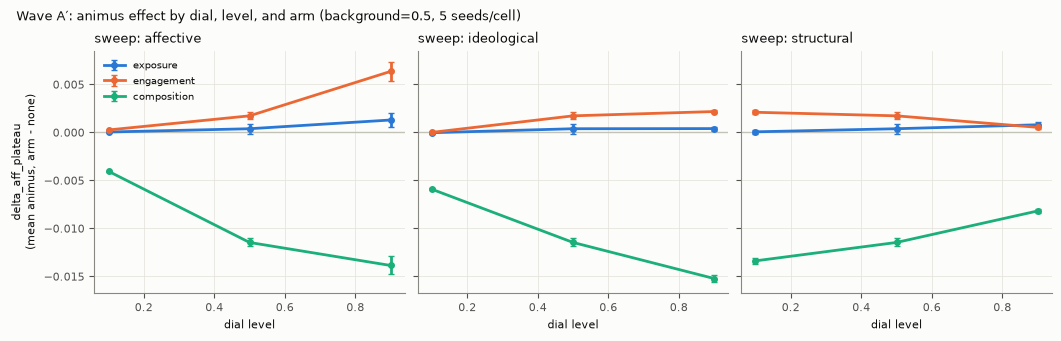

In [2]:
agg = (
    wave_a_prime.group_by(["swept_dial", "level", "arm"])
    .agg(pl.col("delta_aff_plateau").mean().alias("mean"), pl.col("delta_aff_plateau").std().alias("std"))
    .sort(["swept_dial", "arm", "level"])
)

with styled():
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), sharey=True)
    for ax, dial in zip(axes, ["affective", "ideological", "structural"]):
        sub = agg.filter(pl.col("swept_dial") == dial)
        for arm in ARMS:
            s = sub.filter(pl.col("arm") == arm).sort("level")
            ax.errorbar(s["level"], s["mean"], yerr=s["std"].fill_null(0.0), marker="o",
                        label=arm, color=arm_colors[arm], capsize=2)
        ax.axhline(0.0, color=CHROME["baseline"], linewidth=1.0)
        ax.set_title(f"sweep: {dial}", loc="left", fontsize=9)
        ax.set_xlabel("dial level")
    axes[0].set_ylabel("delta_aff_plateau\n(mean animus, arm - none)")
    axes[0].legend(fontsize=7.5)
    fig.suptitle("Wave A′: animus effect by dial, level, and arm (background=0.5, 5 seeds/cell)",
                 x=0.01, ha="left", fontsize=9)
plt.show()


**Reading the grid.** `composition` (green) is negative at every level of
every dial — 45/45 cells — and its magnitude visibly scales with
tribalization (e.g. the affective sweep: -0.0040 at level 0.1 rising to
-0.0158 at level 0.9). `engagement` (orange) is pinned to exactly zero at
`ideological=0.1` on the ideological-sweep panel — not small, exactly
zero — while `exposure` and `composition` stay measurable at that same
point. That is the second, unrelated camp-gate Wave A′ found: the
`engagement`/`composition` arms' manipulation is a `kernel_theta` override on
the `outgroup` feature (`exposure/kernel.py::compute_features`), which only
exists `if camps is not None` — a DIFFERENT consumer of the camp label than
the one `affect_drive="distance"` fixed. `composition` still moves there
because its OTHER lever (`valence_gamma0`, a platform-wide civility shift)
does not depend on camp features at all. No sign flip anywhere in this grid
— H1's falsifier has not fired. `targeting_mode` (§4 below) is the fix.


## 3. Wave B — named scenarios, Latin Hypercube sampling, targeting_mode, and the diversity floor

Three named worlds, each described by MEASURED properties rather than just
its dial preset (brief §5.3's own requirement):


In [3]:
from discourse_lab.experiments.experiment03_bubble_intervention import SCENARIOS, describe_scenario

scenario_table = pl.DataFrame([describe_scenario(s) for s in SCENARIOS.values()])
show(scenario_table)


| scenario | mean_animus | bimodality | camps_defined | emergent_k | cross_camp_tie_share |
| --- | --- | --- | --- | --- | --- |
| consolidated_two_camp | 1.6947 | 0.7791 | True | 2 | 0.1272 |
| cross_cut | 0.8936 | 0.6987 | True | 2 | 0.4759 |
| low_tribalization | 0.2485 | 0.3549 | False | 1 | 0.4843 |

`cross_cut` is deliberately NOT genuine multi-camp fragmentation — this
codebase has no population generator that produces more than two ideological
modes (`emergent_k` above confirms it: exactly 2, same as the other two
scenarios) — it is the closest reachable stratum to "ideologically split but
not structurally sorted": high `bimodality`, near-chance
`cross_camp_tie_share`.

Wave B ran 3 scenarios × 6 Latin Hypercube points per scenario (radius 0.25
around each scenario's own preset) × both `targeting_mode`s × 2 seeds — 72
design points, 216 rows, 1435s (~24 min) wall clock. A sanity check first:
`exposure` never references `kernel_theta`, so its whole trajectory is
bit-identical across `targeting_mode` in all 72 of its rows — confirming the
factor is wired where intended and nowhere else.


### 3a. H3b — does targeting_mode change *which* population an intervention reaches?

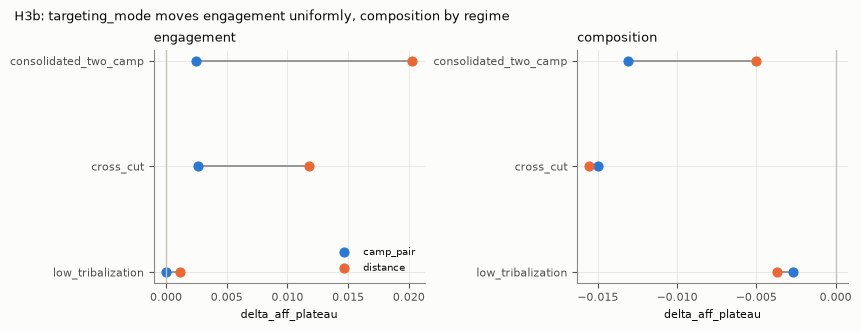

In [4]:
wide = wave_b.pivot(index=["scenario", "lhs_index", "seed", "arm"], on="targeting_mode",
                     values="delta_aff_plateau")
pair_agg = (
    wide.group_by(["scenario", "arm"])
    .agg(pl.col("camp_pair").mean().alias("camp_pair"), pl.col("distance").mean().alias("distance"))
)
scenario_order = {"low_tribalization": 0, "cross_cut": 1, "consolidated_two_camp": 2}

with styled():
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
    mode_colors = series_colors(2)
    for ax, arm in zip(axes, ["engagement", "composition"]):
        sub = pair_agg.filter(pl.col("arm") == arm).sort(
            pl.col("scenario").replace_strict(scenario_order)
        )
        y = np.arange(sub.height)
        ax.hlines(y, sub["camp_pair"], sub["distance"], color=CHROME["muted"], linewidth=1.2, zorder=1)
        ax.scatter(sub["camp_pair"], y, color=mode_colors[0], label="camp_pair", zorder=2, s=40)
        ax.scatter(sub["distance"], y, color=mode_colors[1], label="distance", zorder=2, s=40)
        ax.axvline(0.0, color=CHROME["baseline"], linewidth=1.0)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["scenario"].to_list(), fontsize=8)
        ax.set_title(arm, loc="left", fontsize=9)
        ax.set_xlabel("delta_aff_plateau")
    axes[0].legend(fontsize=7.5, loc="lower right")
    fig.suptitle("H3b: targeting_mode moves engagement uniformly, composition by regime",
                 x=0.01, ha="left", fontsize=9)
plt.show()


**`engagement` (left): `distance` is always more hostility-increasing than
`camp_pair`, in every one of 36/36 cells in all three scenarios** — mean gap
(`camp_pair - distance`) -0.0178 in `consolidated_two_camp`, -0.0091 in
`cross_cut`, -0.0011 in `low_tribalization` (where `camp_pair` is the
known-zero no-op and `distance` is the only one of the two actually doing
anything). **`composition` (right) flips sign by regime**: in
`consolidated_two_camp`, `camp_pair` reduces hostility MORE than `distance`
(mean gap -0.0081, 8/12 cells favor `camp_pair`); in `low_tribalization`,
`distance` reduces it slightly more, with total consistency (12/12 cells,
mean gap +0.0010); `cross_cut` sits between the two, weaker and less
consistent (8/12 favor `distance`). Camp-based and distance-based targeting
are not interchangeable implementations of "the same" manipulation.


### 3b. The viewpoint-diversity floor (SS2.3) — is civility bought at the cost of diversity?

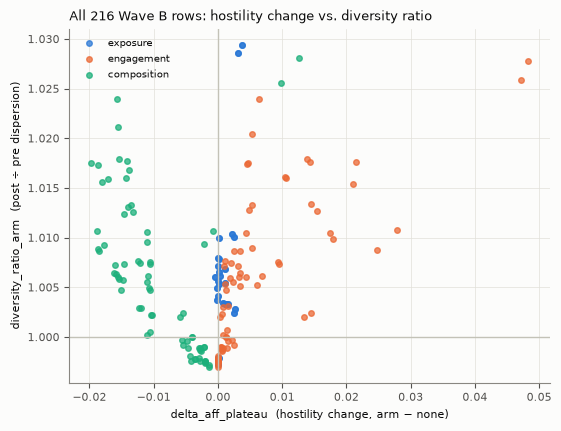

90/216 rows reduced hostility at all (composition 70/72, exposure 20/72, engagement 0/72)
diversity_floor_break_even range where hostility fell: 0.9970 to 1.0239


In [5]:
with styled():
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    for arm in ARMS:
        sub = wave_b.filter(pl.col("arm") == arm)
        ax.scatter(sub["delta_aff_plateau"], sub["diversity_ratio_arm"], s=16, alpha=0.75,
                   color=arm_colors[arm], label=arm)
    ax.axhline(1.0, color=CHROME["baseline"], linewidth=1.0)
    ax.axvline(0.0, color=CHROME["baseline"], linewidth=1.0)
    ax.set_xlabel("delta_aff_plateau  (hostility change, arm − none)")
    ax.set_ylabel("diversity_ratio_arm  (post ÷ pre dispersion)")
    ax.set_title("All 216 Wave B rows: hostility change vs. diversity ratio", loc="left", fontsize=9)
    ax.legend(fontsize=7.5)
plt.show()

justified = wave_b.filter(pl.col("diversity_floor_break_even").is_not_nan())
print(f"{justified.height}/{wave_b.height} rows reduced hostility at all "
      f"(composition {wave_b.filter((pl.col('arm')=='composition') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72, "
      f"exposure {wave_b.filter((pl.col('arm')=='exposure') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72, "
      f"engagement {wave_b.filter((pl.col('arm')=='engagement') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72)")
print(f"diversity_floor_break_even range where hostility fell: "
      f"{justified['diversity_floor_break_even'].min():.4f} to {justified['diversity_floor_break_even'].max():.4f}")


**The floor is barely tested at this scale, because dispersion barely
moves.** Every hostility-reducing cell (90/216 — all but 2 of
`composition`'s, a fifth of `exposure`'s, none of `engagement`'s) lands its
break-even ratio `f` within ~2.4% of 1.0, points above AND below the line
included. SS2.3's central question — is civility worth a diversity cost —
does not yet have a real dilemma to adjudicate here: the two outcomes are
close to orthogonal at this population size and this 100-tick
post-intervention horizon. A longer horizon or a stronger intervention could
change that; this run tests neither.


## 4. Wave C — hysteresis: does the damage persist after the intervention is withdrawn?

`select_hysteresis_points` picks the top-N Wave B cells by seed-averaged
`|delta_aff_plateau|` — the brief's own rule ("only run this where phase 2
produced a significant effect"). All top 3 turned out to be
`engagement`/`targeting_mode="distance"` (2 in `consolidated_two_camp`, 1 in
`cross_cut`) — `engagement`'s hostility-INCREASING effect under `distance`
targeting outsizes `composition`'s hostility-decreasing effect everywhere
Wave B sampled, so this wave tests recovery from a HARM, not from a benefit.


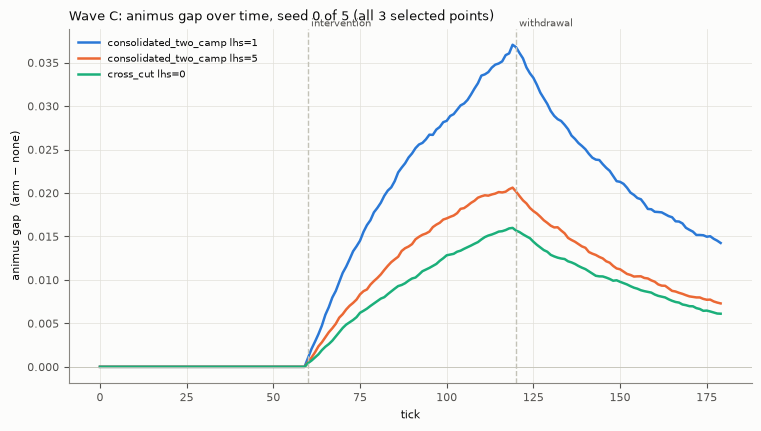

In [6]:
from discourse_lab.experiments.experiment03_bubble_intervention import (
    base_config,
    dial_config,
    run_arm,
    select_hysteresis_points,
)

points = select_hysteresis_points(wave_b, n_points=3).to_dicts()
INTERVENTION_TICK, WITHDRAWAL_TICK, N_TICKS_TOTAL = 60, 120, 180

# Re-reads each point's seed-0 run from the on-disk `cached_run` cache Wave C
# already populated -- no re-simulation, just a full per-tick trajectory
# instead of the two snapshots (`peak_gap`/`final_gap`) `run_hysteresis` kept.
with styled():
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for point, color in zip(points, series_colors(len(points))):
        burn_in = dial_config(
            base_config(1000, N_TICKS_TOTAL), affective=point["affective"],
            ideological=point["ideological"], structural=point["structural"],
        )
        none_cfg, handle_none = run_arm(burn_in, "none", 0, intervention_tick=INTERVENTION_TICK,
                                        n_ticks_total=N_TICKS_TOTAL)
        arm_cfg, handle_arm = run_arm(
            burn_in, point["arm"], 0, intervention_tick=INTERVENTION_TICK, n_ticks_total=N_TICKS_TOTAL,
            targeting_mode=point["targeting_mode"], withdrawal_tick=WITHDRAWAL_TICK,
        )
        none_traj = handle_none.traits_used(none_cfg).group_by("t").agg(pl.col("animus").mean().alias("none")).sort("t")
        arm_traj = handle_arm.traits_used(arm_cfg).group_by("t").agg(pl.col("animus").mean().alias("arm_")).sort("t")
        gap = arm_traj.join(none_traj, on="t").with_columns((pl.col("arm_") - pl.col("none")).alias("gap")).sort("t")
        label = f"{point['scenario']} lhs={point['lhs_index']}"
        ax.plot(gap["t"], gap["gap"], color=color, label=label, linewidth=1.8)

    ax.axvline(INTERVENTION_TICK, color=CHROME["baseline"], linestyle="--", linewidth=1.0)
    ax.axvline(WITHDRAWAL_TICK, color=CHROME["baseline"], linestyle="--", linewidth=1.0)
    ymax = ax.get_ylim()[1]
    ax.text(INTERVENTION_TICK, ymax, " intervention", fontsize=7, va="bottom", color=CHROME["secondary"])
    ax.text(WITHDRAWAL_TICK, ymax, " withdrawal", fontsize=7, va="bottom", color=CHROME["secondary"])
    ax.axhline(0.0, color=CHROME["baseline"], linewidth=0.6)
    ax.set_xlabel("tick")
    ax.set_ylabel("animus gap  (arm − none)")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.set_title("Wave C: animus gap over time, seed 0 of 5 (all 3 selected points)",
                 loc="left", fontsize=9)
plt.show()


| scenario | lhs_index | arm | targeting_mode | recovery_mean | recovery_std | peak_gap_mean | final_gap_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| consolidated_two_camp | 1 | engagement | distance | 0.6279 | 0.0273 | 0.0356 | 0.0132 |
| consolidated_two_camp | 5 | engagement | distance | 0.6351 | 0.0246 | 0.0208 | 0.0076 |
| cross_cut | 0 | engagement | distance | 0.6119 | 0.0231 | 0.0163 | 0.0063 |

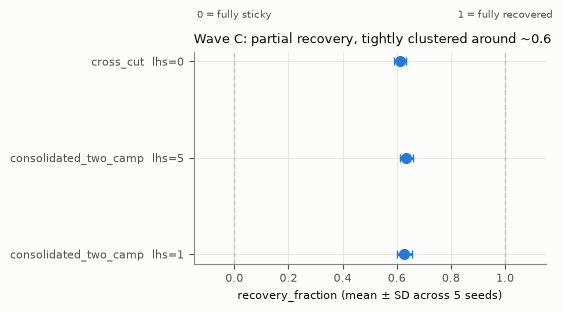

In [7]:
rec_agg = (
    wave_c.group_by(["scenario", "lhs_index", "arm", "targeting_mode"])
    .agg(pl.col("recovery_fraction").mean().alias("recovery_mean"),
         pl.col("recovery_fraction").std().alias("recovery_std"),
         pl.col("peak_gap").mean().alias("peak_gap_mean"),
         pl.col("final_gap").mean().alias("final_gap_mean"))
    .sort(["scenario", "lhs_index"])
)
show(rec_agg)

with styled():
    fig, ax = plt.subplots(figsize=(5.5, 3))
    labels = [f"{r['scenario']}  lhs={r['lhs_index']}" for r in rec_agg.iter_rows(named=True)]
    y = np.arange(len(labels))
    ax.errorbar(rec_agg["recovery_mean"], y, xerr=rec_agg["recovery_std"], fmt="o",
                color=series_colors(1)[0], capsize=3, markersize=7)
    ax.axvline(0.0, color=CHROME["baseline"], linewidth=1.0, linestyle="--")
    ax.axvline(1.0, color=CHROME["baseline"], linewidth=1.0, linestyle="--")
    ax.text(0.0, len(labels) - 0.55, "0 = fully sticky", fontsize=7, ha="center", color=CHROME["secondary"])
    ax.text(1.0, len(labels) - 0.55, "1 = fully recovered", fontsize=7, ha="center", color=CHROME["secondary"])
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(-0.15, 1.15)
    ax.set_xlabel("recovery_fraction (mean ± SD across 5 seeds)")
    ax.set_title("Wave C: partial recovery, tightly clustered around ~0.6", loc="left", fontsize=9)
plt.show()


**Recovery is partial and strikingly consistent**: 61-64% of the peak animus
gap closes in the 60 ticks after withdrawal (a 1:1 withdrawal-to-intervention
tick ratio), leaving 36-39% persistent, in all 3 points across two different
scenarios — despite their peak gaps themselves spanning a 2.5x range (0.015
to 0.037). Neither H4 extreme holds cleanly: not fully sticky (0%), not fully
reversed (100%). The tightness of the cluster despite that magnitude spread
reads as evidence for a roughly fixed relaxation timescale in the animus
dynamics rather than a scenario-specific property — a hypothesis, not
something this one-arm, one-direction sample confirms.

**What this does not test**: whether `composition`'s CIVILITY gain is
equally (a)symmetric. `select_hysteresis_points` ranks by raw magnitude, and
`engagement`'s harm outsized `composition`'s benefit everywhere sampled, so
all 3 points here test withdrawal from a HARM, not a BENEFIT — the brief's
own H4 framing compares the two. A `run_wave_c`-style call seeded with
`composition` points specifically (bypassing the magnitude ranking) would be
needed to complete that comparison.


## 5. Verdict against the brief's hypotheses

| Hypothesis | Status | Evidence |
|---|---|---|
| **H1** — sign of `delta_aff_plateau` flips somewhere in the dial space | Not falsified | Zero sign flips across Wave A (135 rows), Wave A′ (135 rows), and Wave B (216 rows) — `composition` negative, `engagement` non-negative, everywhere sampled |
| **H2** — ideological movement tracks affective movement | Dissociated | `toward_own_pole`'s own background dominates (Wave A′); `toward_other_camp` is negative under EVERY arm in Wave B, `composition` included, even where it is simultaneously reducing animus |
| **H3** — `composition` reduces hostility, `engagement`/`exposure` do not help | Holds | `composition` negative in 100% of cells across all three waves; `engagement` never once reduces hostility in Wave B (0/72) |
| **H3b** — `targeting_mode` (camp vs. distance) changes the outcome | Confirmed, direction depends on arm and regime | Uniform for `engagement` (distance always worse), regime-dependent for `composition` (crosses over between `consolidated_two_camp` and `low_tribalization`) |
| **H4** — the hostile regime is stickier than the civil one | Partially supported, incomplete comparison | 61-64% recovery in 60 ticks after withdrawal — real persistence, not full stickiness; only tested in the harm direction so far |
| **H5** — fragmentation (`delta_k`) responds to the interventions | Not supported at this scale | `delta_k` exactly 0.0 on all 486 rows across every wave (`cross_cut`'s own documented no-`k`>2-generator limitation); `delta_bic_margin` small and non-directional |
| **SS2.3** — diversity floor forces a tradeoff | No real tradeoff observed yet | break-even `f` within ~2.4% of 1.0 in every hostility-reducing Wave B cell — the two outcomes are close to orthogonal at this scale/horizon |


## 6. Scope and deviations

Matching this project's own precedent of stating reductions plainly rather
than letting a reader assume the brief's full scale ran:

1. **Wave A / A′** are a one-factor-at-a-time sign screen (5 seeds × 3
   levels × 3 dials), not a true Morris elementary-effects design — the
   brief's own §5.4 names Morris screening explicitly; a real Morris design
   needs multiple random trajectories through the 3-dial space to estimate
   global sensitivity, out of scope for this pass.
2. **Wave B** ran 6 Latin Hypercube points × 2 seeds per scenario, not the
   brief's own §5.3 default (~30 points, 10 seeds) — a ~1/20 reduction,
   matching Wave A's own precedent. No response-surface regression was fit
   over the collected LHS points; that is a separate, not-yet-built analysis
   step.
3. **Wave C** ran on 3 points (5 seeds each), selected by raw effect
   magnitude rather than by arm — see §4's own caveat about testing only the
   harm direction.
4. **No calibration against a real corpus** (brief §8) anywhere in this
   project — still entirely out of scope.
5. **`cross_cut`** is NOT genuine multi-camp fragmentation (§3's own note):
   this codebase's population generator cannot produce more than two
   ideological modes, so `delta_k` stays flat at 0.0 by construction on
   every design point sampled across all four waves, regardless of what the
   interventions do.

Full numeric write-up, including every number cited above and the mechanism-
level root causes behind the two camp-gates this project found along the
way, is in `FINDINGS.md`.
